In [189]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [190]:
netflix=pd.read_csv("C:\\Users\\dawit\\PycharmProjects\\Netflix Content Evolution\\data\\netflix_cleaned.csv")

In [191]:
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,added_year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021


In [192]:
netflix['date_added']=pd.to_datetime(netflix['date_added'].str.strip())

In [193]:
netflix.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
added_year               int64
dtype: object

In [194]:
netflix['duration'].head(20)

0        90 min
1     2 Seasons
2      1 Season
3      1 Season
4     2 Seasons
5      1 Season
6        91 min
7       125 min
8     9 Seasons
9       104 min
10     1 Season
11     1 Season
12      127 min
13       91 min
14     1 Season
15    4 Seasons
16       67 min
17    2 Seasons
18       94 min
19     1 Season
Name: duration, dtype: str

In [195]:
netflix['duration'].info()

<class 'pandas.Series'>
RangeIndex: 8797 entries, 0 to 8796
Series name: duration
Non-Null Count  Dtype
--------------  -----
8797 non-null   str  
dtypes: str(1)
memory usage: 68.9 KB


In [196]:
netflix['duration'].value_counts()

duration
1 Season     1793
2 Seasons     421
3 Seasons     198
90 min        152
94 min        146
             ... 
228 min         1
18 min          1
205 min         1
201 min         1
191 min         1
Name: count, Length: 220, dtype: int64

In [197]:
netflix_tv_show=netflix[netflix['type']=='TV Show']
netflix_tv_show['duration'].value_counts()

duration
1 Season      1793
2 Seasons      421
3 Seasons      198
4 Seasons       94
5 Seasons       64
6 Seasons       33
7 Seasons       23
8 Seasons       17
9 Seasons        9
10 Seasons       6
13 Seasons       2
15 Seasons       2
12 Seasons       2
17 Seasons       1
11 Seasons       1
Name: count, dtype: int64

In [198]:
netflix_tv_show['duration']=netflix_tv_show['duration'].str.split(" ",n=1).str[0].astype(int)
netflix_tv_show['duration'].head()

1    2
2    1
3    1
4    2
5    1
Name: duration, dtype: int64

In [199]:
def statistics(data):
    return pd.DataFrame(
        {
            'mean':np.mean(data),
            'count':data.count(),
            'standard deviation':data.std(),
            'minimum':data.min(),
            'median':data.median(),
            'maximum':data.max(),
            '25th quartile':np.quantile(data,q=0.25),
            '75th quartile':np.quantile(data,q=0.75),
            'IQR':np.quantile(data,q=0.75)-np.quantile(data,q=0.25)
        },index=[0]
    )
statistics(netflix_tv_show['duration'])

,mean,count,standard deviation,minimum,median,maximum,25th quartile,75th quartile,IQR
0,1.751313,2666,1.550176,1,1.0,17,1.0,2.0,1.0


In [200]:
netflix_tv_show['duration'].value_counts()

duration
1     1793
2      421
3      198
4       94
5       64
6       33
7       23
8       17
9        9
10       6
13       2
15       2
12       2
17       1
11       1
Name: count, dtype: int64

In [201]:
netflix_tv_show_duration_by_year=pd.get_dummies(netflix_tv_show,columns=['duration'],dtype=int).groupby('added_year').sum(numeric_only=True).drop(columns='release_year')
netflix_tv_show_duration_by_year

,duration_1,duration_2,duration_3,duration_4,duration_5,duration_6,duration_7,duration_8,duration_9,duration_10,duration_11,duration_12,duration_13,duration_15,duration_17
added_year,,,,,,,,,,,,,,,
2008,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2013,2,0,0,1,1,1,0,0,0,0,0,0,0,0,0
2014,0,0,2,0,2,0,0,1,0,0,0,0,0,0,0
2015,14,4,1,2,1,0,3,0,0,1,0,0,0,0,0
2016,140,17,8,2,6,0,1,0,2,0,0,0,0,0,0
2017,253,41,22,14,7,3,3,4,0,0,1,1,0,0,0
2018,292,61,26,10,8,5,4,3,0,1,0,1,0,1,0
2019,414,103,46,8,9,4,1,4,2,0,0,0,1,0,0
2020,383,97,43,32,14,10,5,4,3,3,0,0,0,1,0


In [202]:
netflix_tv_show_duration_proportion=netflix_tv_show_duration_by_year.div(netflix_tv_show_duration_by_year.sum(axis=1),axis=0)*100
netflix_tv_show_duration_proportion

,duration_1,duration_2,duration_3,duration_4,duration_5,duration_6,duration_7,duration_8,duration_9,duration_10,duration_11,duration_12,duration_13,duration_15,duration_17
added_year,,,,,,,,,,,,,,,
2008,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
2013,40.000000,0.000000,0.000000,20.000000,20.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
2014,0.000000,0.000000,40.000000,0.000000,40.000000,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
2015,53.846154,15.384615,3.846154,7.692308,3.846154,0.000000,11.538462,0.000000,0.000000,3.846154,0.000000,0.000000,0.000000,0.000000,0.00000
2016,79.545455,9.659091,4.545455,1.136364,3.409091,0.000000,0.568182,0.000000,1.136364,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
2017,72.492837,11.747851,6.303725,4.011461,2.005731,0.859599,0.859599,1.146132,0.000000,0.000000,0.286533,0.286533,0.000000,0.000000,0.00000
2018,70.873786,14.805825,6.310680,2.427184,1.941748,1.213592,0.970874,0.728155,0.000000,0.242718,0.000000,0.242718,0.000000,0.242718,0.00000
2019,69.932432,17.398649,7.770270,1.351351,1.520270,0.675676,0.168919,0.675676,0.337838,0.000000,0.000000,0.000000,0.168919,0.000000,0.00000
2020,64.369748,16.302521,7.226891,5.378151,2.352941,1.680672,0.840336,0.672269,0.504202,0.504202,0.000000,0.000000,0.000000,0.168067,0.00000


In [203]:
netflix_tv_show_duration_by_year['duration_4+']=netflix_tv_show_duration_by_year['duration_4']
netflix_tv_show_duration_by_year=netflix_tv_show_duration_by_year.drop(columns=['duration_4'])
for i in range(5,18):
    if i not in (14,16):
        netflix_tv_show_duration_by_year['duration_4+']=netflix_tv_show_duration_by_year[['duration_4+',f'duration_{i}']].sum(axis=1)
        netflix_tv_show_duration_by_year=netflix_tv_show_duration_by_year.drop(columns=[f'duration_{i}'])
netflix_tv_show_duration_by_year

,duration_1,duration_2,duration_3,duration_4+
added_year,,,,
2008,1,0,0,0
2013,2,0,0,3
2014,0,0,2,3
2015,14,4,1,7
2016,140,17,8,11
2017,253,41,22,33
2018,292,61,26,33
2019,414,103,46,29
2020,383,97,43,72


In [204]:
netflix_tv_show_duration_proportion=netflix_tv_show_duration_by_year.div(netflix_tv_show_duration_by_year.sum(axis=1),axis=0)*100
netflix_tv_show_duration_proportion

,duration_1,duration_2,duration_3,duration_4+
added_year,,,,
2008,100.000000,0.000000,0.000000,0.000000
2013,40.000000,0.000000,0.000000,60.000000
2014,0.000000,0.000000,40.000000,60.000000
2015,53.846154,15.384615,3.846154,26.923077
2016,79.545455,9.659091,4.545455,6.250000
2017,72.492837,11.747851,6.303725,9.455587
2018,70.873786,14.805825,6.310680,8.009709
2019,69.932432,17.398649,7.770270,4.898649
2020,64.369748,16.302521,7.226891,12.100840


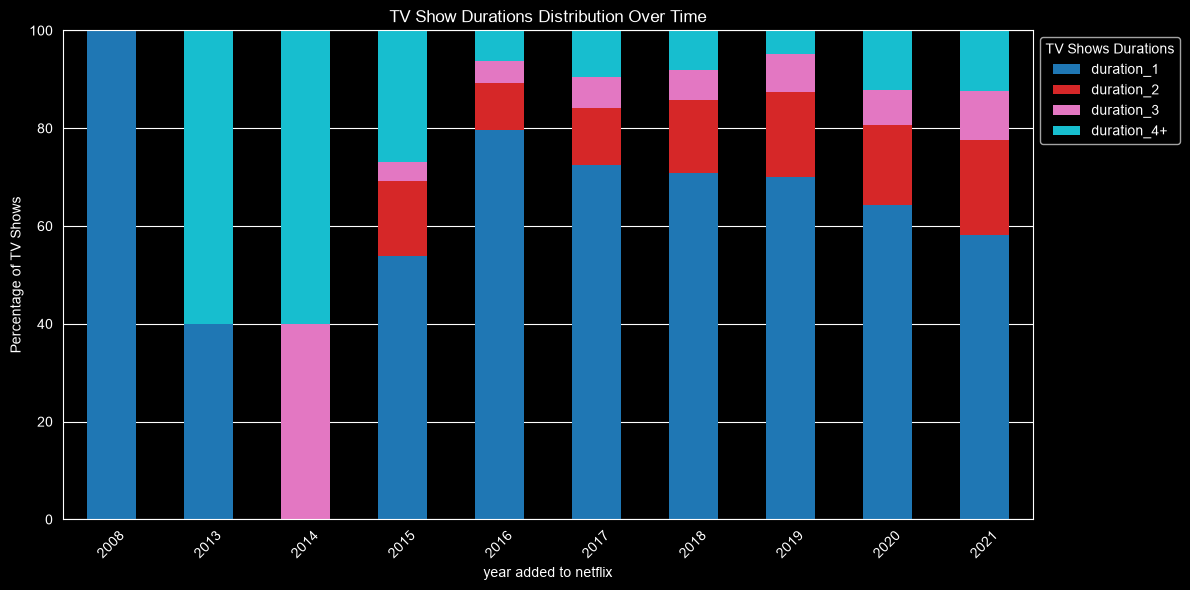

In [205]:
netflix_tv_show_duration_proportion.plot(kind='bar',stacked=True,figsize=(12,6),edgecolor='none',colormap='tab10')
plt.title('TV Show Durations Distribution Over Time')
plt.xlabel('year added to netflix')
plt.ylabel('Percentage of TV Shows')
plt.legend(title='TV Shows Durations',loc='upper left',bbox_to_anchor=(1,1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:\\Users\\dawit\\PycharmProjects\\Netflix Content Evolution\\images\\TV Show Durations.png',dpi=300,bbox_inches='tight')

In [206]:
stats_tv_show_2016_2021=statistics(netflix_tv_show[netflix_tv_show['added_year']==2016]['duration']).assign(year=2016).set_index('year')
for i in range(2017,2022):
    stat=statistics(netflix_tv_show[netflix_tv_show['added_year']==i]['duration']).assign(year=i).set_index('year')
    stats_tv_show_2016_2021=pd.concat([stats_tv_show_2016_2021,stat],axis=0)
stats_tv_show_2016_2021

,mean,count,standard deviation,minimum,median,maximum,25th quartile,75th quartile,IQR
year,,,,,,,,,
2016,1.482955,176,1.278278,1,1.0,9,1.0,1.0,0.0
2017,1.679083,349,1.521925,1,1.0,12,1.0,2.0,1.0
2018,1.677184,412,1.566114,1,1.0,15,1.0,2.0,1.0
2019,1.569257,592,1.244385,1,1.0,13,1.0,2.0,1.0
2020,1.853782,595,1.643413,1,1.0,15,1.0,2.0,1.0
2021,1.956436,505,1.690920,1,1.0,17,1.0,2.0,1.0


In [207]:
netflix_movies=netflix[netflix['type']=='Movie']
netflix_movies['duration'].shape

(6131,)

In [208]:
netflix_movies['duration'].head(10)

0      90 min
6      91 min
7     125 min
9     104 min
12    127 min
13     91 min
16     67 min
18     94 min
22    161 min
23     61 min
Name: duration, dtype: str

In [209]:
netflix_movies['duration']=netflix_movies['duration'].str.split(" ",n=1).str[0].astype(int)
netflix_movies['duration'].head()

0      90
6      91
7     125
9     104
12    127
Name: duration, dtype: int64

In [210]:
statistics(netflix_movies['duration'])

,mean,count,standard deviation,minimum,median,maximum,25th quartile,75th quartile,IQR
0,99.564998,6131,28.289504,3,98.0,312,87.0,114.0,27.0


In [211]:
stats_movies_2008_2021=statistics(netflix_movies[netflix_movies['added_year']==2008]['duration']).assign(year=2008).set_index('year')
for i in range(2009,2022):
    stat=statistics(netflix_movies[netflix_movies['added_year']==i]['duration']).assign(year=i).set_index('year')
    stats_movies_2008_2021=pd.concat([stats_movies_2008_2021,stat],axis=0)
stats_movies_2008_2021

,mean,count,standard deviation,minimum,median,maximum,25th quartile,75th quartile,IQR
year,,,,,,,,,
2008,81.000000,1,NaN,81,81.0,81,81.00,81.00,0.00
2009,66.500000,2,53.033009,29,66.5,104,47.75,85.25,37.50
2010,84.000000,1,NaN,84,84.0,84,84.00,84.00,0.00
2011,93.461538,13,6.132093,75,94.0,103,93.00,95.00,2.00
2012,62.000000,3,31.432467,26,76.0,84,51.00,80.00,29.00
2013,83.500000,6,29.022405,44,77.5,130,72.75,95.00,22.25
2014,77.000000,19,21.936778,26,78.0,105,71.00,93.50,22.50
2015,83.571429,56,24.433105,29,82.0,155,72.00,92.00,20.00
2016,83.545455,253,24.727301,22,88.0,180,71.00,97.00,26.00


In [212]:
netflix_movies['duration'].value_counts()

duration
90     152
94     146
97     146
93     146
91     144
      ... 
228      1
18       1
205      1
201      1
191      1
Name: count, Length: 205, dtype: int64

In [213]:
netflix_movies_duration_by_year=pd.get_dummies(netflix_movies,columns=['duration'],dtype=int).groupby('added_year').sum(numeric_only=True).drop(columns='release_year')
netflix_movies_duration_by_year

,duration_3,duration_5,duration_8,duration_9,duration_10,duration_11,duration_12,duration_13,duration_14,duration_15,...,duration_214,duration_224,duration_228,duration_229,duration_230,duration_233,duration_237,duration_253,duration_273,duration_312
added_year,,,,,,,,,,,,,,,,,,,,,
2008,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2009,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2010,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2012,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2013,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2015,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [214]:
netflix_movies_duration_by_year['duration_under_60']=netflix_movies_duration_by_year['duration_3']
netflix_movies_duration_by_year=netflix_movies_duration_by_year.drop(columns=['duration_3'])
netflix_movies_duration_by_year['duration_60_89']=netflix_movies_duration_by_year['duration_60']
netflix_movies_duration_by_year=netflix_movies_duration_by_year.drop(columns=['duration_60'])
netflix_movies_duration_by_year['duration_90_119']=netflix_movies_duration_by_year['duration_90']
netflix_movies_duration_by_year=netflix_movies_duration_by_year.drop(columns=['duration_90'])
netflix_movies_duration_by_year['duration_120_149']=netflix_movies_duration_by_year['duration_120']
netflix_movies_duration_by_year=netflix_movies_duration_by_year.drop(columns=['duration_120'])
netflix_movies_duration_by_year['duration_over_150']=netflix_movies_duration_by_year['duration_150']
netflix_movies_duration_by_year=netflix_movies_duration_by_year.drop(columns=['duration_150'])
for i in range(3,313):
    if f'duration_{i}' in netflix_movies_duration_by_year.columns:
        if 3< i <60:
            netflix_movies_duration_by_year['duration_under_60']=netflix_movies_duration_by_year[['duration_under_60',f'duration_{i}']].sum(axis=1)
            netflix_movies_duration_by_year=netflix_movies_duration_by_year.drop(columns=[f'duration_{i}'])
        elif 60< i <90:
            netflix_movies_duration_by_year['duration_60_89']=netflix_movies_duration_by_year[['duration_60_89',f'duration_{i}']].sum(axis=1)
            netflix_movies_duration_by_year=netflix_movies_duration_by_year.drop(columns=[f'duration_{i}'])
        elif 90< i < 120:
            netflix_movies_duration_by_year['duration_90_119']=netflix_movies_duration_by_year[['duration_90_119',f'duration_{i}']].sum(axis=1)
            netflix_movies_duration_by_year=netflix_movies_duration_by_year.drop(columns=[f'duration_{i}'])
        elif 120 < i < 150:
            netflix_movies_duration_by_year['duration_120_149']=netflix_movies_duration_by_year[['duration_120_149',f'duration_{i}']].sum(axis=1)
            netflix_movies_duration_by_year=netflix_movies_duration_by_year.drop(columns=[f'duration_{i}'])
        elif i>150:
            netflix_movies_duration_by_year['duration_over_150']=netflix_movies_duration_by_year[['duration_over_150',f'duration_{i}']].sum(axis=1)
            netflix_movies_duration_by_year=netflix_movies_duration_by_year.drop(columns=[f'duration_{i}'])
netflix_movies_duration_by_year

,duration_under_60,duration_60_89,duration_90_119,duration_120_149,duration_over_150
added_year,,,,,
2008,0,1,0,0,0
2009,1,0,1,0,0
2010,0,1,0,0,0
2011,0,1,12,0,0
2012,1,2,0,0,0
2013,1,3,1,1,0
2014,3,9,7,0,0
2015,6,31,13,5,1
2016,35,96,114,5,3


In [215]:
netflix_movies_duration_proportion=netflix_movies_duration_by_year.div(netflix_movies_duration_by_year.sum(axis=1),axis=0)*100
netflix_movies_duration_proportion

,duration_under_60,duration_60_89,duration_90_119,duration_120_149,duration_over_150
added_year,,,,,
2008,0.000000,100.000000,0.000000,0.000000,0.000000
2009,50.000000,0.000000,50.000000,0.000000,0.000000
2010,0.000000,100.000000,0.000000,0.000000,0.000000
2011,0.000000,7.692308,92.307692,0.000000,0.000000
2012,33.333333,66.666667,0.000000,0.000000,0.000000
2013,16.666667,50.000000,16.666667,16.666667,0.000000
2014,15.789474,47.368421,36.842105,0.000000,0.000000
2015,10.714286,55.357143,23.214286,8.928571,1.785714
2016,13.833992,37.944664,45.059289,1.976285,1.185771


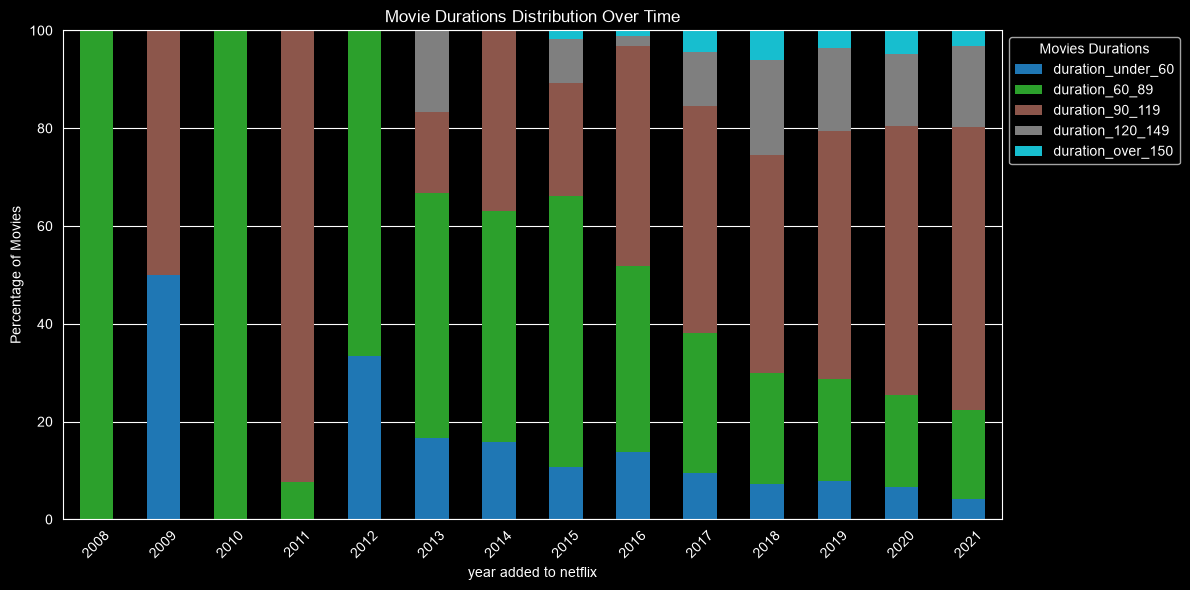

In [216]:
netflix_movies_duration_proportion.plot(kind='bar',stacked=True,figsize=(12,6),edgecolor='none',colormap='tab10')
plt.title('Movie Durations Distribution Over Time')
plt.xlabel('year added to netflix')
plt.ylabel('Percentage of Movies')
plt.legend(title='Movies Durations',loc='upper left',bbox_to_anchor=(1,1))
plt.xticks(rotation=45)
plt.tight_layout()

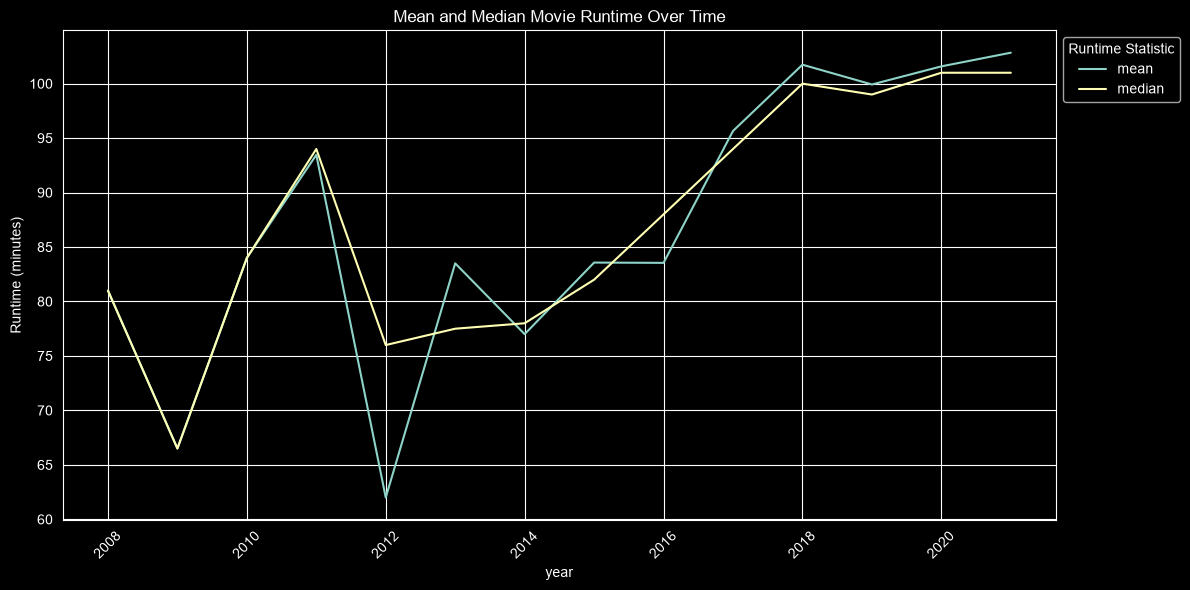

In [217]:
stats_movies_2008_2021.plot(y=['mean','median'],figsize=(12,6))
plt.title('Mean and Median Movie Runtime Over Time')
plt.xlabel('year')
plt.ylabel('Runtime (minutes)')
plt.legend(title='Runtime Statistic',loc='upper left',bbox_to_anchor=(1,1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:\\Users\\dawit\\PycharmProjects\\Netflix Content Evolution\\images\\Mean_and_Median_Movie_Runtime.png',dpi=300,bbox_inches='tight')